In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [2]:
# Colab 첫 셀에서 설치
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.8 MB/s eta 0:00:00


In [3]:

import FinanceDataReader as fdr
import pandas as pd
import numpy as np

# 코스피 시총 상위 50개 구성 종목 확인하기

kospi = fdr.StockListing('KOSPI')
top50 = kospi.nlargest(50, 'Marcap')  # 시총 기준 상위 50
tickers = top50['Code'].tolist()

In [4]:
# 가격 데이터 수집 (2020~2024)
prices = {}
for ticker in tickers:
    try:
        df = fdr.DataReader(ticker, '2020-01-01', '2024-12-31')['Close']
        prices[ticker] = df
    except:
        pass

price_df = pd.DataFrame(prices).dropna(axis=1, thresh=200) #thresh=200 → 유효한 값(NaN 아닌 것)이 200개 미만이면 그 종목 열을 통째로 삭제
print(price_df.shape)  # (거래일수, 종목수) 확인


(1231, 50)


In [5]:
# 월별 종가로 리샘플링
monthly_prices = price_df.resample('ME').last()
monthly_returns = monthly_prices.pct_change()

print(f"월별 데이터: {monthly_prices.shape}")  # (월수, 종목수)
print(f"월별 데이터: {monthly_prices.iloc[:10, :10]}")  # (월수, 종목수)

월별 데이터: (60, 50)
월별 데이터:             005930  000660  402340  005935  009150  005380  373220  032830  \
Date                                                                         
2020-01-31   56400   93500     NaN   47500  125000  125000     NaN   69500   
2020-02-29   54200   87900     NaN   45550  126000  115000     NaN   58500   
2020-03-31   47750   83300     NaN   40100   97700   88700     NaN   43000   
2020-04-30   50000   83700     NaN   42250  113500   93600     NaN   49100   
2020-05-31   50700   81500     NaN   42850  125000   98000     NaN   45700   
2020-06-30   52800   85100     NaN   46500  129000   97700     NaN   44700   
2020-07-31   57900   82800     NaN   49500  140500  126500     NaN   47550   
2020-08-31   54000   75100     NaN   47500  124500  176500     NaN   61200   
2020-09-30   58200   84000     NaN   50500  139000  178500     NaN   61000   
2020-10-31   56600   79900     NaN   50100  133500  164500     NaN   63200   

            329180  028260  
Date     

In [6]:
# 12개월 모멘텀 계산
# 예: 2021년 12월 기준 → 2020년 12월 대비 2021년 11월 수익률
def compute_momentum(prices, lookback=12, skip=1):
    result = {}
    for i, date in enumerate(prices.index):
        if i < lookback:
            continue
        past  = prices.iloc[i - lookback]   # 12개월 전 가격
        recent = prices.iloc[i - skip]       # 1개월 전 가격 (당월 제외)
        result[date] = (recent / past) - 1
    return pd.DataFrame(result).T

momentum_df = compute_momentum(monthly_prices)
print(momentum_df.shape)  # (유효 월수, 종목수)

(48, 50)


In [7]:
# 확인용: 특정 시점 종목별 모멘텀 스코어
sample_date = momentum_df.index[-1]  # 가장 최근 월
print(f"\n{sample_date.strftime('%Y-%m')} 기준 모멘텀 상위 10개:")
print(momentum_df.loc[sample_date].nlargest(10))


2024-12 기준 모멘텀 상위 10개:
267260    3.251825
298040    1.492279
012450    1.426374
010130    1.369478
000150    1.055378
010120    0.967213
064350    0.902256
105560    0.778189
138040    0.725888
329180    0.705426
Name: 2024-12-31 00:00:00, dtype: float64


In [8]:
# 매월 모멘텀 상위 10종목 동일비중 매수 전략
strategy_returns = []
dates = momentum_df.index

for i, date in enumerate(dates[:-1]):
    scores = momentum_df.loc[date].dropna()

    # 모멘텀 스코어 하위 종목 제거 (음수 모멘텀 종목 제외)
    scores = scores[scores > 0]
    if len(scores) < 10:
        continue

    top10 = scores.nlargest(10).index  # 상위 10종목 선택
    next_date = dates[i + 1]

    if next_date in monthly_returns.index:
        ret = monthly_returns.loc[next_date, top10].mean()  # 동일비중 수익률
        strategy_returns.append({'date': next_date, 'return': ret})

strategy_df = pd.DataFrame(strategy_returns).set_index('date')
print(f"전략 기간: {strategy_df.index[0].strftime('%Y-%m')} ~ {strategy_df.index[-1].strftime('%Y-%m')}")
print(f"총 {len(strategy_df)}개월 운용")

전략 기간: 2021-02 ~ 2024-12
총 44개월 운용


In [9]:
# 벤치마크: KOSPI200 지수
ks200 = fdr.DataReader('KS200', '2020-01-01', '2024-12-31')['Close']
ks200_monthly = ks200.resample('ME').last().pct_change()

# 전략 기간에 맞게 정렬
bm = ks200_monthly.reindex(strategy_df.index)

In [10]:
# 핵심 성과 지표 계산
def performance_summary(returns, name="전략"):
    r = returns.dropna()

    cagr    = (1 + r).prod() ** (12 / len(r)) - 1
    sharpe  = r.mean() / r.std() * np.sqrt(12)
    cum     = (1 + r).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    win_rate = (r > 0).mean()  # 월 승률

    print(f"{'='*30}")
    print(f"  [{name}]")
    print(f"  CAGR     : {cagr:>8.1%}")
    print(f"  Sharpe   : {sharpe:>8.2f}")
    print(f"  MDD      : {mdd:>8.1%}")
    print(f"  월 승률   : {win_rate:>8.1%}")
    print(f"{'='*30}")

performance_summary(strategy_df['return'], "모멘텀 전략")
performance_summary(bm, "KOSPI200 BM")

  [모멘텀 전략]
  CAGR     :    33.7%
  Sharpe   :     1.12
  MDD      :   -19.7%
  월 승률   :    54.5%
  [KOSPI200 BM]
  CAGR     :    -4.6%
  Sharpe   :    -0.18
  MDD      :   -30.0%
  월 승률   :    45.5%


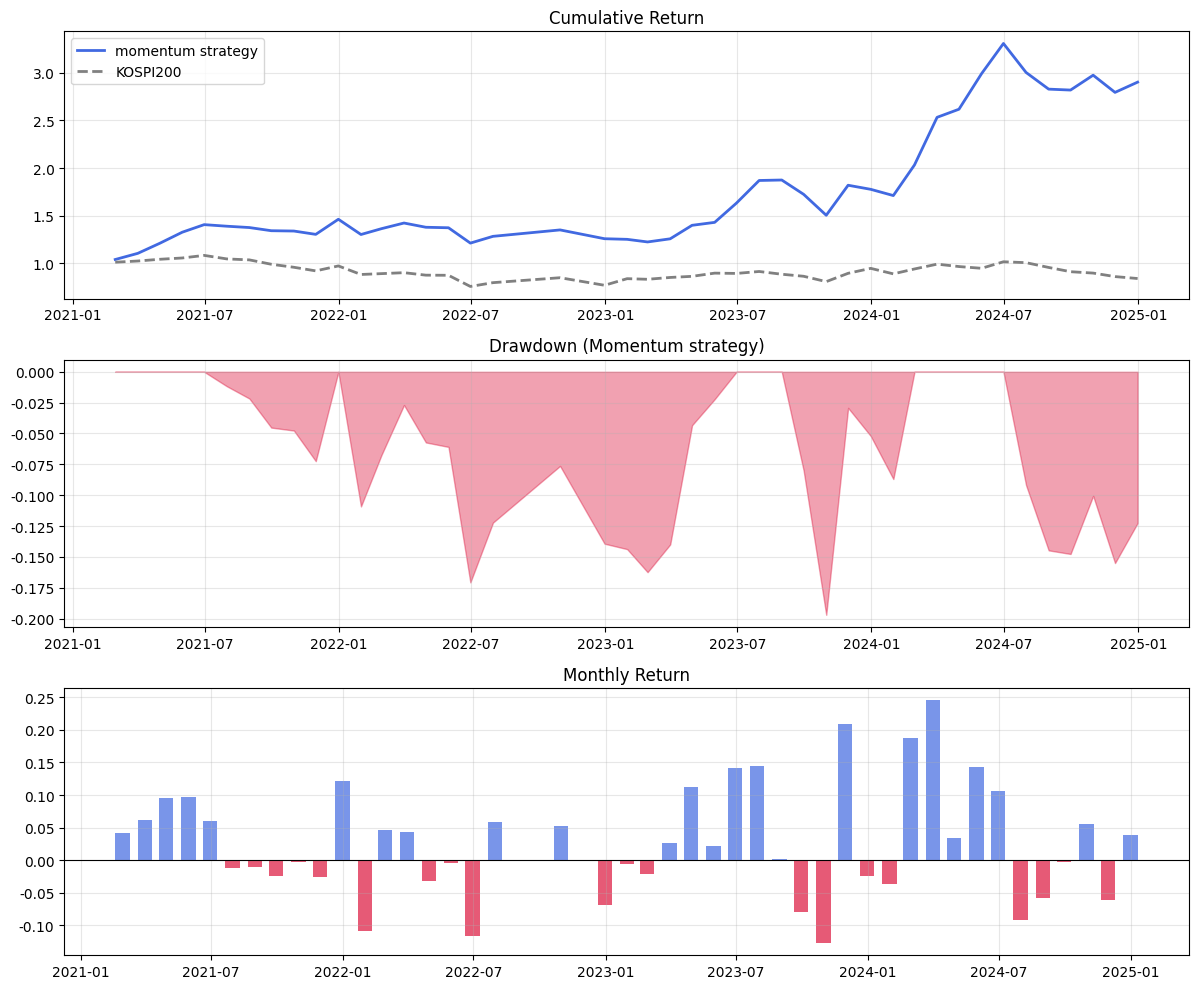

In [11]:
# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1) 누적수익률
cum_strategy = (1 + strategy_df['return']).cumprod()
cum_bm       = (1 + bm).cumprod()

axes[0].plot(cum_strategy, label='momentum strategy', linewidth=2, color='royalblue')
axes[0].plot(cum_bm,       label='KOSPI200',   linewidth=2, color='gray', linestyle='--')
axes[0].set_title('Cumulative Return')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2) MDD
rolling_max = cum_strategy.cummax()
drawdown    = (cum_strategy - rolling_max) / rolling_max
axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.4, color='crimson')
axes[1].set_title('Drawdown (Momentum strategy)')
axes[1].grid(alpha=0.3)

# 3) 월별 수익률 막대
colors = ['royalblue' if r >= 0 else 'crimson' for r in strategy_df['return']]
axes[2].bar(strategy_df.index, strategy_df['return'], color=colors, alpha=0.7, width=20)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Monthly Return')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()